<a href="https://colab.research.google.com/github/qiyuechen1202/CASA0010_thesis/blob/main/20250429_PMP_Sample.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# The P-median Problem (PMP) Model


## STEP1: Installing the library

In [74]:
! pip install gurobipy

In [75]:
! pip install --upgrade fiona
! pip install --upgrade pyproj

## STEP2: Loading the library

In [76]:
#modelling tool_Mathematical optimization (Gurobi)
import gurobipy as gp
from gurobipy import *
from itertools import product
# Data Processing
import pandas as pd
import geopandas as gpd
import numpy as np
# Spatial and geometry tools
from shapely.geometry import Point
from shapely.ops import unary_union
from geopy.distance import distance
from scipy.spatial.distance import cdist
# Visualization
import matplotlib.pyplot as plt
 # Basic mathematical operations
from math import sqrt


## STEP3: Obtaining license for Using Gurobi

Gurobi is a tool for solving mathematical optimisation problems, which has been applied in various industries to tackle complex mathematical programming challenges (GUROBI, 2020). By employing Gurobi, the research could find the global optimum under the given constraints.

Running this PMP model need to using Gurobi Optimiser and applying a valid Gurobi license:


- For Colab -using free academic Web License Service (WLS)
license: https://www.gurobi.com/features/academic-wls-license/?_gl=1*fw2555*_up*MQ..*_gs*MQ..&gclid=Cj0KCQjw5azABhD1ARIsAA0WFUHuVOQAhp_gGIPfUJjbMDlRxJlzW347XMJSbo39FX21HteEF17cga8aAhK2EALw_wcB&gbraid=0AAAAA-OoJU7NjWQFciqeNs4M01R-u6uR1

Regarding the WLS license, the WLS file can be download form Web License Manager obtain the information, including "WLSACCESSID","WLSSECRET" and "LICENSEID".

- Applying other license types: https://www.gurobi.com/academia/academic-program-and-licenses/?gad_source=1&gbraid=0AAAAA-OoJU7NjWQFciqeNs4M01R-u6uR1&gclid=Cj0KCQjw5azABhD1ARIsAA0WFUHuVOQAhp_gGIPfUJjbMDlRxJlzW347XMJSbo39FX21HteEF17cga8aAhK2EALw_wcB

In [77]:
# Create an environment with the WLS license
params = {
"WLSACCESSID": '',
"WLSSECRET": '',
"LICENSEID": ,
}
env = gp.Env(params=params)

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2658999
Academic license 2658999 - for non-commercial use only - registered to li___@postgrad.manchester.ac.uk


## STEP4: Loading the data
Data List:
* Demand points - Point data
* Facilities (Piont of Interest) - Point data
* Geographic data (London Boundary & Developable area)

In [78]:
#clone the repository that contains the data and code for the PMP Model
!git clone https://github.com/qiyuechen1202/CASA0010_thesis

fatal: destination path 'CASA0010_thesis' already exists and is not an empty directory.


In [79]:
wd = 'CASA0010_thesis/PMP_Sample/Data/'
# 1. Demand Point- original hexagon centroids
unique_ori= gpd.read_file(wd + 'unique_ori.geojson').to_crs(epsg=27700)
# transfering the list of demand points
demand_points = unique_ori['geometry'].to_list()

In [80]:
# 2. Facilities (POI data)
poi= gpd.read_file(wd + 'poi_name.geojson').to_crs(epsg=27700)
# Extracting a certain type of POI
poi_cul = poi[poi['poi_name']=='Culture']
# transfering the list of amenity points
facility_points = poi_cul['geometry'].to_list()

In [81]:
# 3. Geographic Data(Visualising)
# London Boundary data
london_boundary= gpd.read_file(wd + 'lb.geojson')

# -defining the region of London Boundary
london_boundary_polygon = london_boundary.geometry.unary_union


<ipython-input-81-e3f1757058fb>:6: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  london_boundary_polygon = london_boundary.geometry.unary_union


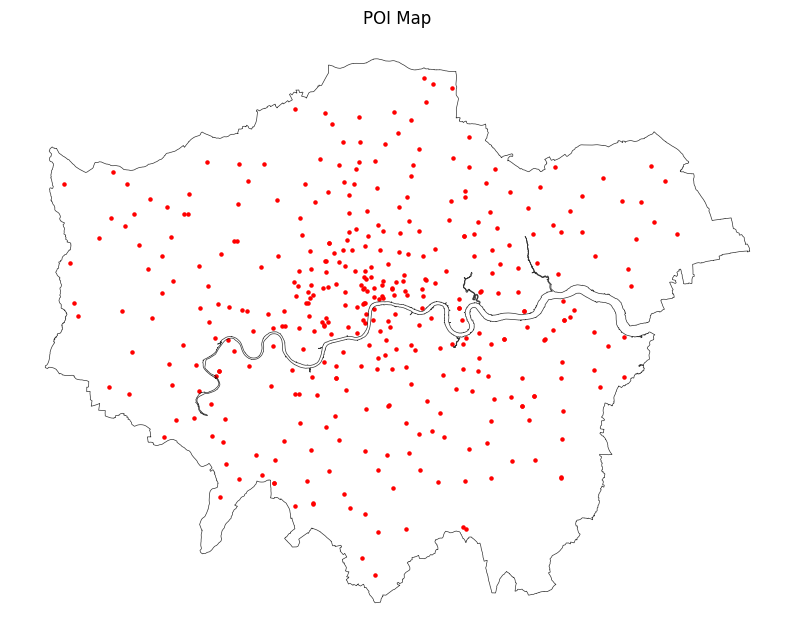

In [82]:
# Visualising the POI data
fig, ax = plt.subplots(figsize=(10, 8))
poi_cul.plot(ax=ax, color='red', markersize=5, label='Existing Facilities')
london_boundary.plot(ax=ax, color='none', edgecolor='black', linewidth=0.5, aspect='equal',alpha=0.8)
ax.set_title('POI Map')
ax.set_axis_off()
plt.show()

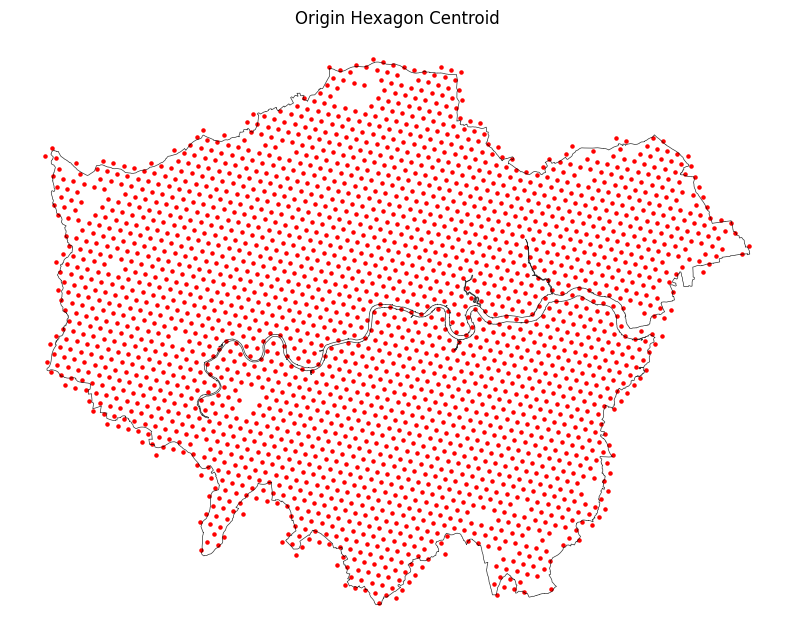

In [83]:
# Visualising the Origin Hexagon (Centroids)
fig, ax = plt.subplots(figsize=(10, 8))
unique_ori.plot(ax=ax, color='red', markersize=5, label='Existing Facilities')
london_boundary.plot(ax=ax, color='none', edgecolor='black', linewidth=0.5, aspect='equal',alpha=0.8)
ax.set_title('Origin Hexagon Centroid')
ax.set_axis_off()
plt.show()

## STEP5: Setting the PMP Model

In [84]:
# Create a the Gurobi model for the PMP Model
m = gp.Model("p-median Problem", env=env)

In [85]:
# Create variables
# Binary variable X: indicates whether each facility point is selected (1) or not (0)
select = m.addVars(len(facility_points), vtype=GRB.BINARY, name='Select')
# Create the Cartesian product of all demand and facility point indices
cartesian_prod = list(product(range(len(demand_points)), range(len(facility_points))))
# Binary variable Y: indicates whether a demand point is assigned to a specific facility (1) or not (0)
assign = m.addVars(cartesian_prod, vtype=GRB.BINARY, name='Assign')

In [86]:
# Create constraint
num_located = 381 # Number of facilities to select;
# Constraint 1: The total number of selected facilities must equal num_located，meaning all facilities are selected.
m.addConstr((quicksum(select[j] for j in range(len(facility_points))) == num_located), name='Num_limit')
# Constraint 2: A demand point can only be assigned to a facility if that facility is selected
m.addConstrs((assign[i, j] <= select[j] for i, j in cartesian_prod), name='Assign_before_locate')
# Constraint 3: Each demand point must be assigned to exactly one facility
m.addConstrs((quicksum(assign[i, j] for j in range(len(facility_points))) == 1 for i in range(len(demand_points))), name='Unique_assign')

{0: <gurobi.Constr *Awaiting Model Update*>,
 1: <gurobi.Constr *Awaiting Model Update*>,
 2: <gurobi.Constr *Awaiting Model Update*>,
 3: <gurobi.Constr *Awaiting Model Update*>,
 4: <gurobi.Constr *Awaiting Model Update*>,
 5: <gurobi.Constr *Awaiting Model Update*>,
 6: <gurobi.Constr *Awaiting Model Update*>,
 7: <gurobi.Constr *Awaiting Model Update*>,
 8: <gurobi.Constr *Awaiting Model Update*>,
 9: <gurobi.Constr *Awaiting Model Update*>,
 10: <gurobi.Constr *Awaiting Model Update*>,
 11: <gurobi.Constr *Awaiting Model Update*>,
 12: <gurobi.Constr *Awaiting Model Update*>,
 13: <gurobi.Constr *Awaiting Model Update*>,
 14: <gurobi.Constr *Awaiting Model Update*>,
 15: <gurobi.Constr *Awaiting Model Update*>,
 16: <gurobi.Constr *Awaiting Model Update*>,
 17: <gurobi.Constr *Awaiting Model Update*>,
 18: <gurobi.Constr *Awaiting Model Update*>,
 19: <gurobi.Constr *Awaiting Model Update*>,
 20: <gurobi.Constr *Awaiting Model Update*>,
 21: <gurobi.Constr *Awaiting Model Update*>

In [87]:
# calculate the distance (can be changed to actual network distance for OD pairs)
def compute_distance(loc1, loc2):
    return loc1.distance(loc2)
# Calculate the distance for all pairs of demand points and facility points
dist = {(i, j): compute_distance(demand_points[i], facility_points[j]) for i, j in cartesian_prod}

In [88]:
# Set the objective: Minimize the overall distance between assigned demand points and selected facility points
m.setObjective(quicksum(dist[i, j] * assign[i, j] for i, j in cartesian_prod), GRB.MINIMIZE)

In [89]:
# Run the PMP model
m.optimize()

Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (linux64 - "Ubuntu 22.04.4 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Academic license 2658999 - for non-commercial use only - registered to li___@postgrad.manchester.ac.uk
Optimize a model with 951945 rows, 949833 columns and 2848737 nonzeros
Model fingerprint: 0x22f28c93
Variable types: 0 continuous, 949833 integer (949833 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [3e+01, 6e+04]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 4e+02]
Found heuristic solution: objective 4.799564e+07
Presolve removed 949453 rows and 381 columns
Presolve time: 1.28s
Presolved: 2492 rows, 949452 columns, 949452 nonzeros
Variable types: 0 continuous, 949452 integer (949452 binary)
Performing another presolve...
Presolve removed 0 rows and 946960 columns
Presolve time: 0.58s
Found heuristic

In [90]:
# Print the results
selected_facilities = [j for j in range(len(facility_points)) if select[j].x > 0]
assigned_relationships = [(i, j) for (i, j) in cartesian_prod if assign[i, j].x > 0.5]
print("Selected positions = ", selected_facilities)
print("Assigned relationships = ", assigned_relationships)
print('Objvalue = %g' % m.objVal)

Selected positions =  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 21

## STEP6: Visualising the PMP Model Problems

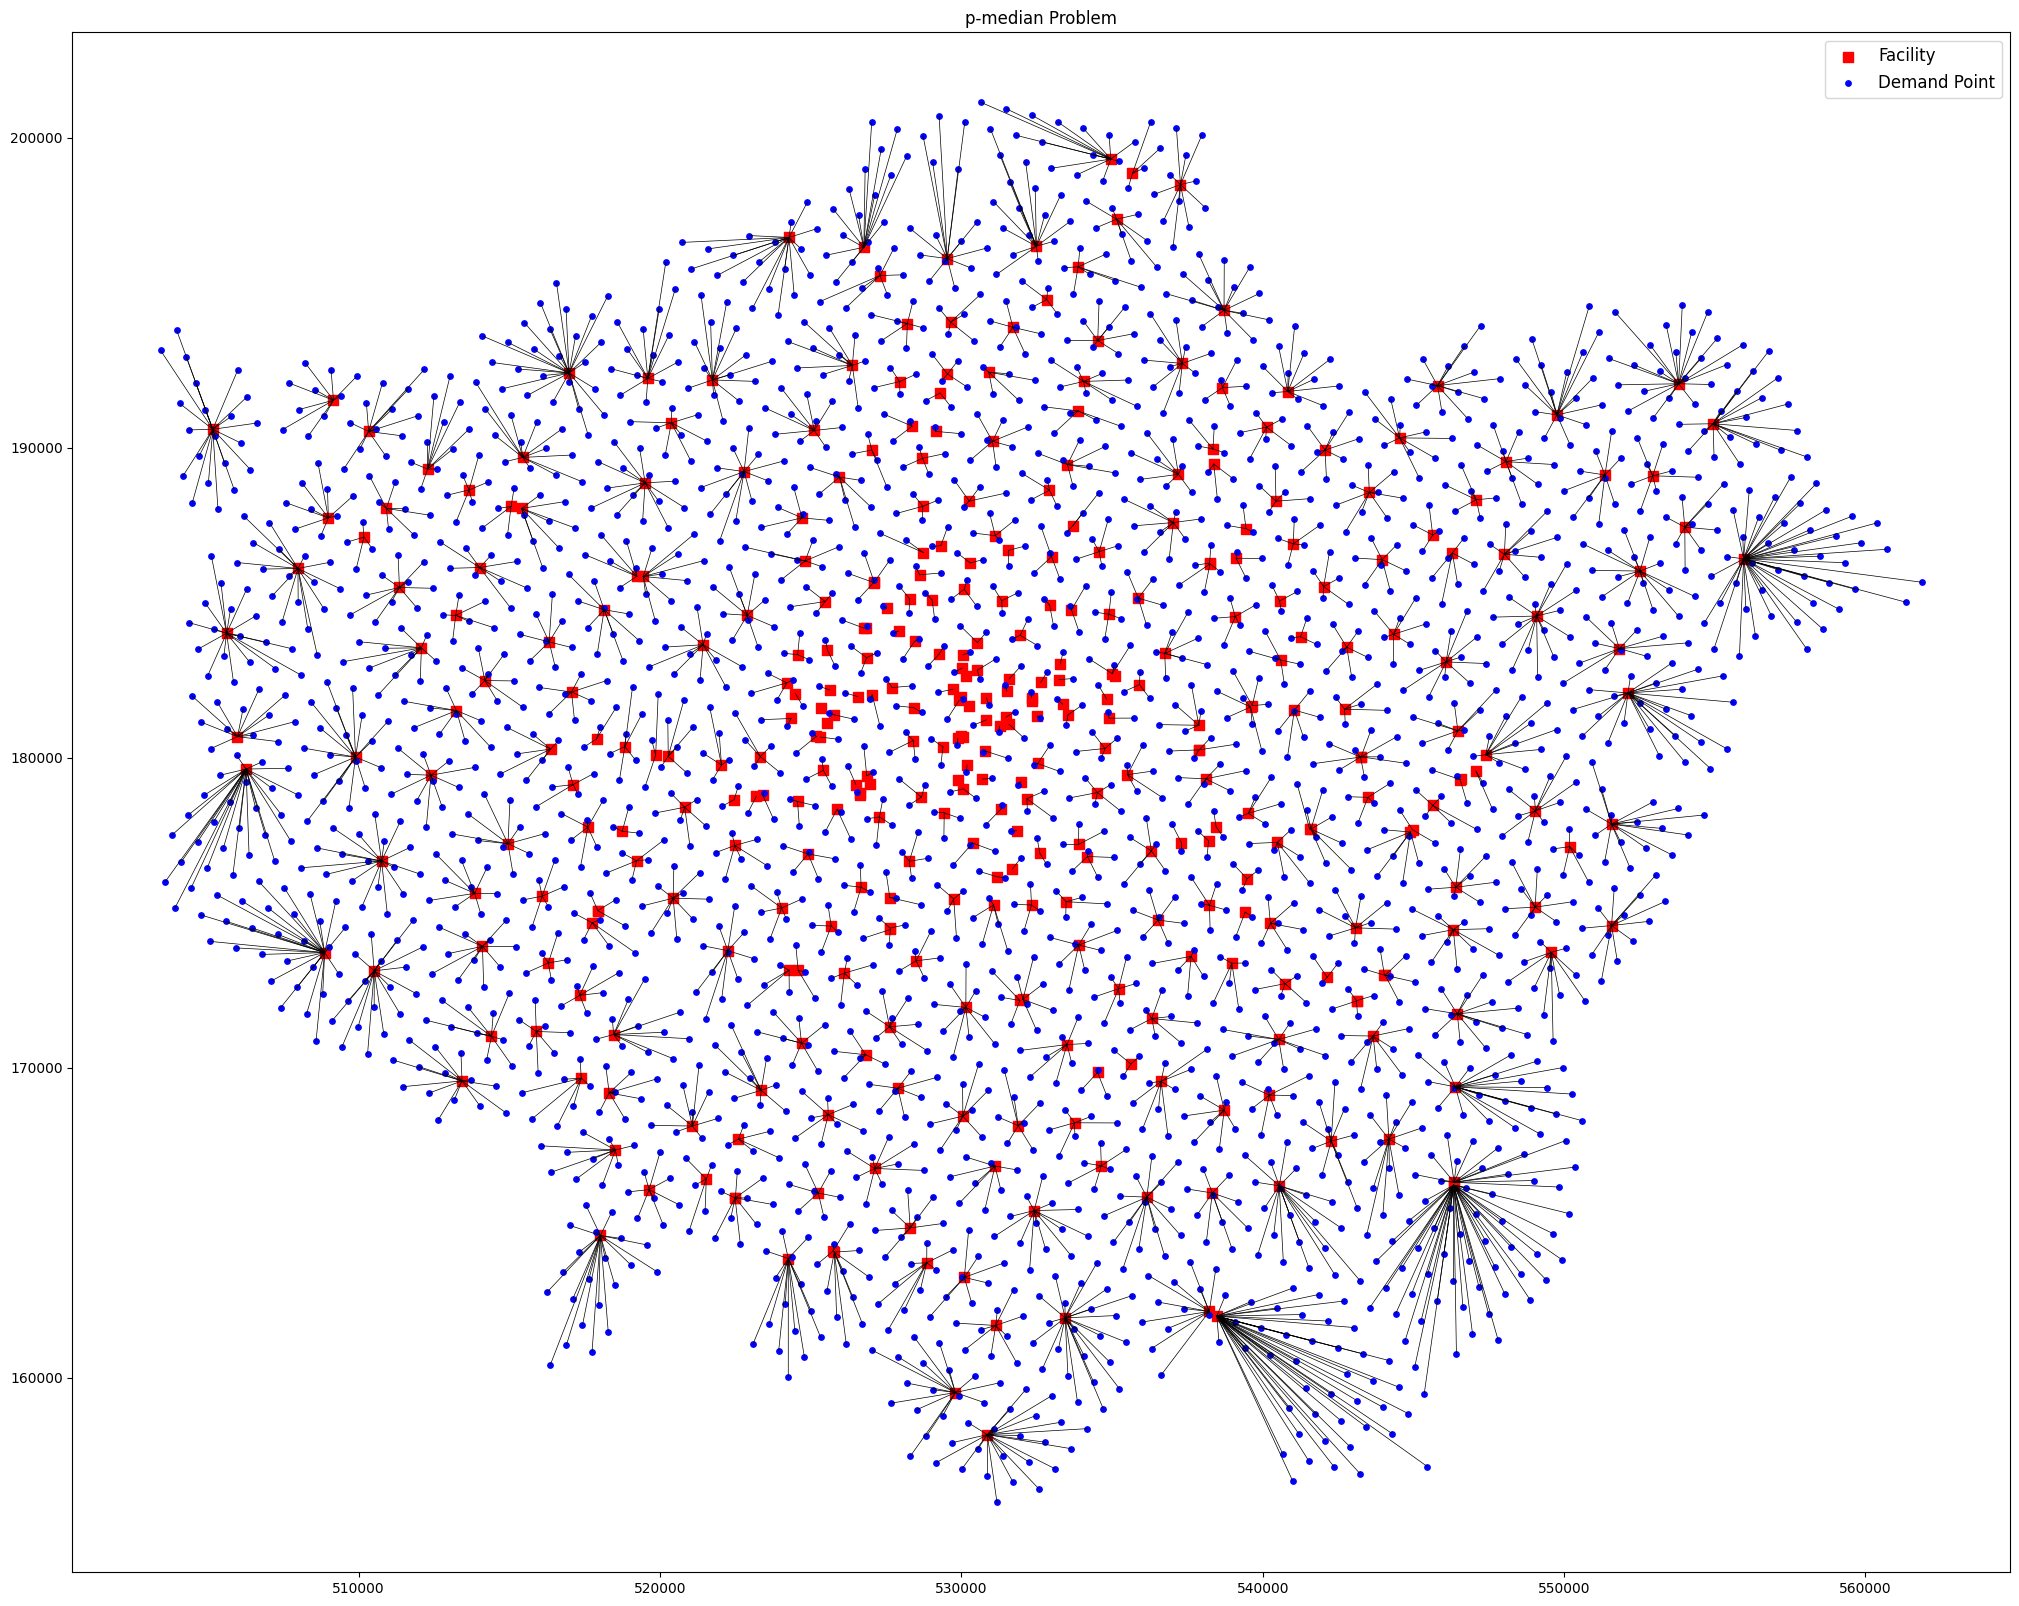

In [91]:
# Create a figure
plt.figure(figsize=(25, 20))
plt.title('p-median Problem')

# Plot existing facility points
facility_x = [p.x for p in facility_points]
facility_y = [p.y for p in facility_points]
plt.scatter(facility_x, facility_y, c='Red', marker='s', s=50, label='Facility')

# Plot demand points
demand_x = [p.x for p in demand_points]
demand_y = [p.y for p in demand_points]
plt.scatter(demand_x, demand_y, c='Blue', marker='o', s=15, label='Demand Point')

# Plot the lines representing assignment relationships between demand points and facilities
for (i, j) in assigned_relationships:
    plt.plot([demand_points[i].x, facility_points[j].x], [demand_points[i].y, facility_points[j].y], c='Black', linewidth=0.5)

# Drawing
plt.legend(loc='best', fontsize=12)
plt.show()